# SHAP Analysis

## Setup and Imports

In [1]:
import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.pipeline import Pipeline

from src.config import settings
from src.experiments.training.enums import ModelFamily
from src.experiments.training.models import build_model_spec
from src.utils import load_latest_dataset
from src.utils.analysis import (
    best_per_model_family,
    build_run_artifact_version,
    configure_notebook_plots,
    load_training_run_artifacts,
    select_training_run_dir,
    select_variant_rows,
)

np.random.seed(settings.random_seed)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
configure_notebook_plots(figsize=(8, 6))
artifacts_dir = Path("artifacts")
shap_root = artifacts_dir / "shap"
shap_root.mkdir(parents=True, exist_ok=True)

## 1. Data Loading and Validation


In [3]:
df, manifest, version_path = load_latest_dataset(data_dir="../data/processed")
label_cols = [
    "has_pyproject_toml",
    "has_dockerfile",
    "has_github_actions",
]
all_label_cols = [col for col in settings.variant_label_columns if col in df.columns]
feature_cols = [
    col for col in df.columns if col != "repo_url" and col not in set(all_label_cols)
]

if not feature_cols:
    raise ValueError("No feature columns available after excluding all labels.")

class_target = (
    df[label_cols]
    .copy()
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
    .rename("label_combination")
)

print("Metadata:")
print(f"  Dataset version: {manifest.get('version', 'unknown')}")
print(f"  Manifest created: {manifest.get('created_at', 'unknown')}")
print(f"  Source commit: {str(manifest.get('git_commit', 'unknown'))[:8]}")
print(f"  Combination labels (from): {label_cols}")
print(f"  Unique classes present: {class_target.nunique()}")
print(f"  Excluded label columns: {len(all_label_cols)}")
print(f"  Features: {len(feature_cols)}")

Metadata:
  Dataset version: 1.0.1
  Manifest created: 2026-04-01T19:45:24.483060+00:00
  Source commit: 4f490c29
  Combination labels (from): ['has_pyproject_toml', 'has_dockerfile', 'has_github_actions']
  Unique classes present: 8
  Excluded label columns: 10
  Features: 32


## 2. Model Selection from Training Outputs

In [4]:
training_run_id: str | None = (
    None  # if run_id is not specified, last run id will be used
)
selected_variant: str = "original"

In [5]:
training_root = Path("../logs/training")
selected_run_dir, _ = select_training_run_dir(training_root, training_run_id)
cv_summary, run_config, refit_metric, refit_col = load_training_run_artifacts(
    selected_run_dir,
    fallback_refit_metric=settings.training_gridsearch_refit_metric,
)
variant_rows = select_variant_rows(cv_summary, selected_variant, refit_col)

best_row = variant_rows.iloc[0]
best_model_family = ModelFamily(best_row["model_family"])
model_selection = best_per_model_family(variant_rows, refit_col)
model_rows_by_family: dict[ModelFamily, dict[str, Any]] = {
    ModelFamily(row["model_family"]): row.to_dict()
    for _, row in variant_rows.drop_duplicates("model_family", keep="first").iterrows()
}

artifact_version = build_run_artifact_version(selected_run_dir.name, run_config)
shap_dir = shap_root / artifact_version
shap_dir.mkdir(parents=True, exist_ok=True)

print("Selected training run:")
print(f"  Run ID: {selected_run_dir.name}")
print(f"  Variant: {selected_variant}")
print(f"  Refit metric: {refit_metric}")
print(f"  Best model family: {best_model_family.value}")
print(f"  Artifact version: {artifact_version}")
display(model_selection[["model_family", refit_col]])

Selected training run:
  Run ID: 20260413_155156
  Variant: original
  Refit metric: f1_weighted
  Best model family: gradient_boosting
  Artifact version: 20260413_155156_v1.0.1


,model_family,f1_weighted_mean
0,gradient_boosting,0.475957
1,random_forest,0.457664
2,decision_tree,0.432125
3,neural_network,0.403942
4,svm,0.385860


## 3. SHAP Setup

In [6]:
X = df[feature_cols].copy()
X = X.apply(pd.to_numeric, errors="raise").astype(np.float64)
y = class_target.copy()

shap_sample_size = min(300, len(X))
shap_background_size = min(100, len(X))
shap_max_evals = 400

X_eval_df = shap.sample(
    X, shap_sample_size, random_state=settings.random_seed
).reset_index(drop=True)
X_background_df = shap.sample(
    X, shap_background_size, random_state=settings.random_seed
).reset_index(drop=True)
X_eval_df = X_eval_df.astype(np.float64)
X_background_df = X_background_df.astype(np.float64)

print(f"SHAP eval sample size: {len(X_eval_df)}")
print(f"SHAP background size: {len(X_background_df)}")
print(f"Class count: {y.nunique()}")
print(f"SHAP matrix dtypes: {X_eval_df.dtypes.unique().tolist()}")

SHAP eval sample size: 300
SHAP background size: 100
Class count: 8
SHAP matrix dtypes: [dtype('float64')]


## 4. SHAP Value Computation (Multiclass Combination Target)


In [7]:
def build_training_estimator(
    model_family: ModelFamily, best_params_json: str, *, n_features: int
) -> Any:
    """Build the exact training estimator/pipeline and load best GridSearch params."""
    model_spec = build_model_spec(model_family, n_features=n_features)
    estimator = model_spec.pipeline
    estimator.set_params(**json.loads(best_params_json))
    return estimator


def predict_multiclass_score(
    estimator: Any, data: np.ndarray | pd.DataFrame
) -> np.ndarray:
    """Return one aggregate confidence score per sample for multiclass SHAP."""
    data_np = np.asarray(data, dtype=np.float64)
    if data_np.ndim == 1:
        data_np = data_np.reshape(1, -1)
    data_df = pd.DataFrame(data_np, columns=feature_cols)

    if hasattr(estimator, "predict_proba"):
        probs = np.asarray(estimator.predict_proba(data_df), dtype=np.float64)
        if probs.ndim == 1:
            return probs
        return probs.max(axis=1)

    if hasattr(estimator, "decision_function"):
        decisions = np.asarray(estimator.decision_function(data_df), dtype=np.float64)
        if decisions.ndim == 1:
            return decisions
        return decisions.max(axis=1)

    preds = np.asarray(estimator.predict(data_df))
    classes = np.asarray(getattr(estimator, "classes_", np.unique(preds)))
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    return np.asarray([class_to_idx.get(value, 0) for value in preds], dtype=np.float64)


def collapse_multiclass_tree_explanation(
    explanation: shap.Explanation,
) -> shap.Explanation:
    """Collapse multiclass SHAP values to one class-aggregate explanation."""
    values = np.asarray(explanation.values)
    if values.ndim == 2:
        return explanation
    if values.ndim != 3:
        raise ValueError(f"Unsupported SHAP values shape: {values.shape}")

    if values.shape[1] == len(feature_cols):
        collapsed_values = values.mean(axis=2)
    elif values.shape[2] == len(feature_cols):
        collapsed_values = values.mean(axis=1)
    else:
        raise ValueError(
            "Unable to infer feature axis in SHAP values with shape "
            f"{values.shape} for {len(feature_cols)} features."
        )

    base_values = explanation.base_values
    collapsed_base: Any = base_values
    if isinstance(base_values, np.ndarray) and base_values.ndim == 2:
        collapsed_base = base_values.mean(axis=1)

    return shap.Explanation(
        values=collapsed_values,
        base_values=collapsed_base,
        data=explanation.data,
        feature_names=explanation.feature_names,
    )

In [8]:
shap_results: dict[str, shap.Explanation] = {}
fitted_models: dict[str, Any] = {}

for model_family, row in model_rows_by_family.items():
    family_key = model_family.value
    estimator = build_training_estimator(
        model_family,
        row["best_params_json"],
        n_features=len(feature_cols),
    )
    estimator.fit(X, y)

    is_binary_task = len(np.unique(y)) <= 2
    if model_family in {
        ModelFamily.DECISION_TREE,
        ModelFamily.RANDOM_FOREST,
    } or (model_family == ModelFamily.GRADIENT_BOOSTING and is_binary_task):
        tree_model = (
            estimator.named_steps["model"]
            if isinstance(estimator, Pipeline)
            else estimator
        )
        explainer = shap.TreeExplainer(tree_model)
        raw_shap_vals = explainer(X_eval_df)
        shap_vals = collapse_multiclass_tree_explanation(raw_shap_vals)
    else:
        explainer = shap.PermutationExplainer(
            lambda data, estimator=estimator: predict_multiclass_score(estimator, data),
            X_background_df,
        )
        shap_vals = explainer(X_eval_df, max_evals=shap_max_evals)

    shap_vals.feature_names = feature_cols

    fitted_models[family_key] = estimator
    shap_results[family_key] = shap_vals

print(f"Computed SHAP for families: {list(shap_results.keys())}")

PermutationExplainer explainer: 301it [01:33,  3.04it/s]                         
PermutationExplainer explainer: 301it [1:38:16, 19.85s/it]                              

Computed SHAP for families: ['gradient_boosting', 'random_forest', 'decision_tree', 'neural_network', 'svm']


## 5. SHAP Summary Plots


/tmp/ipykernel_1322/376128265.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


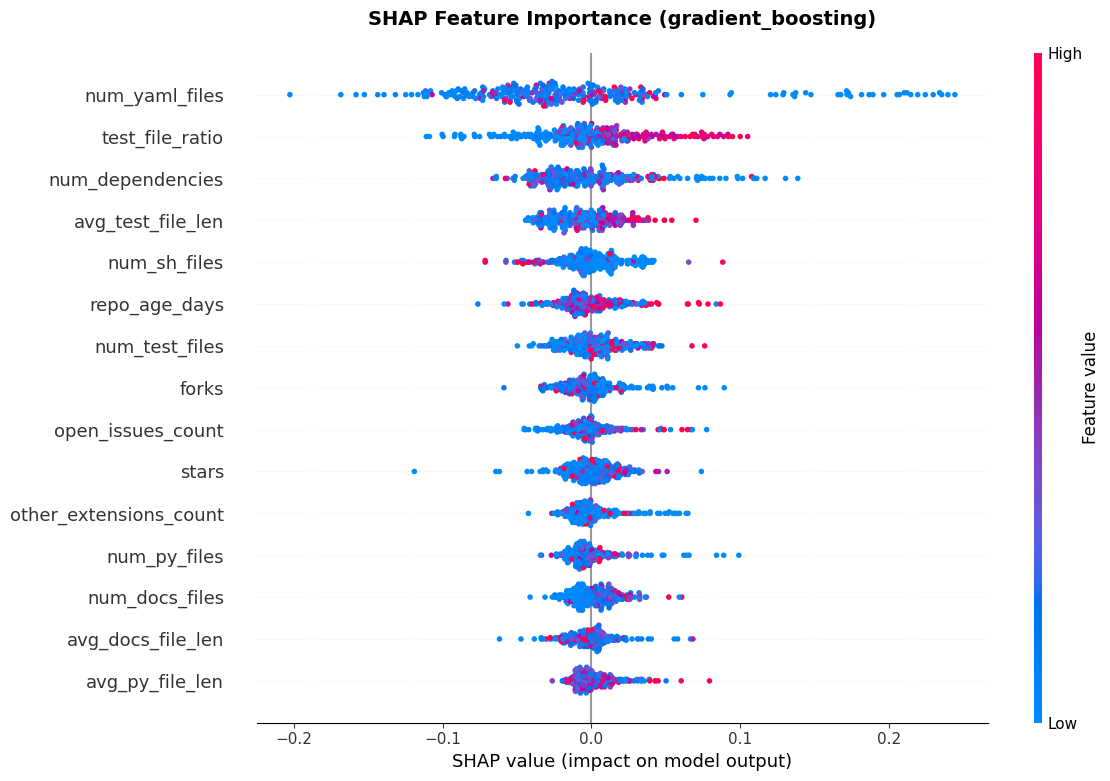

/tmp/ipykernel_1322/376128265.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


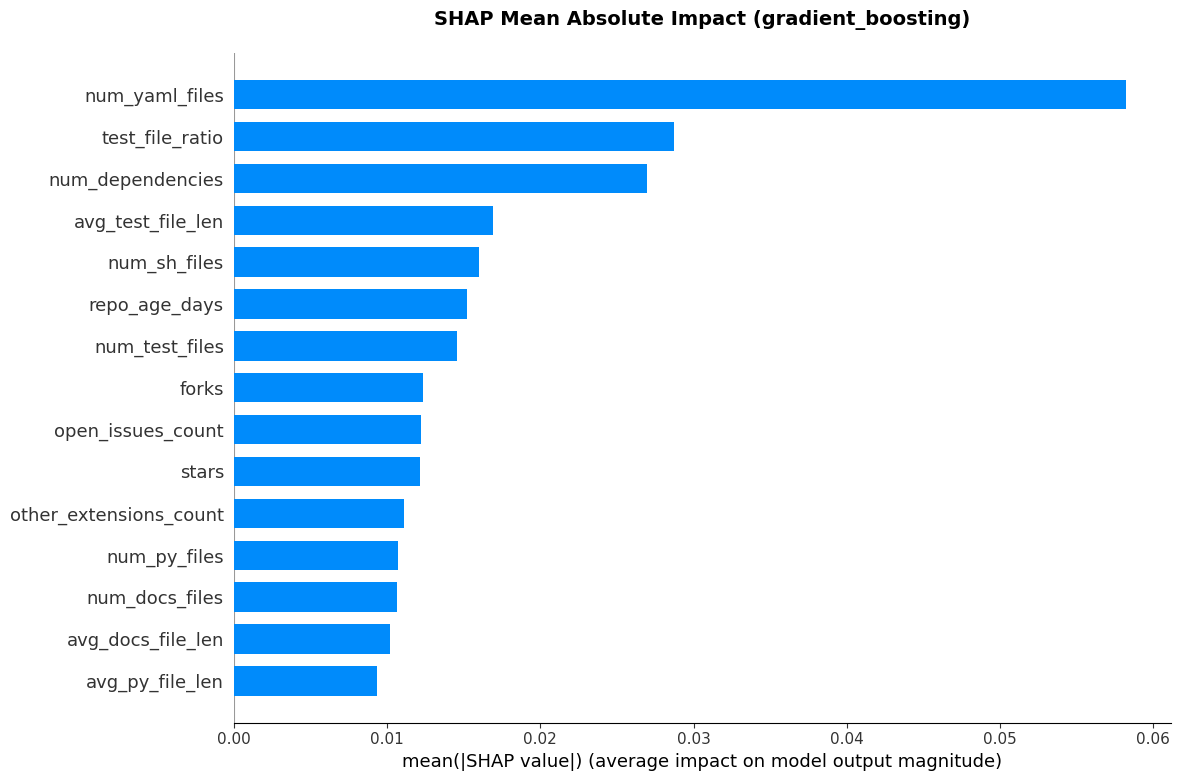

/tmp/ipykernel_1322/376128265.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


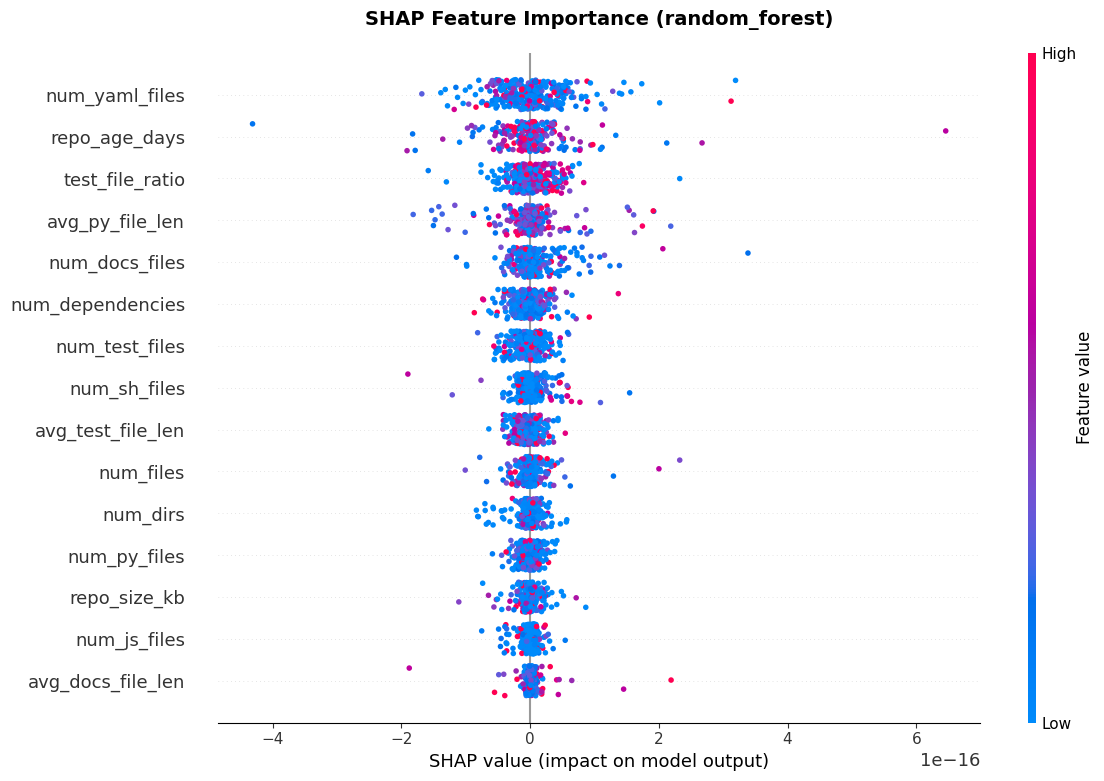

/tmp/ipykernel_1322/376128265.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


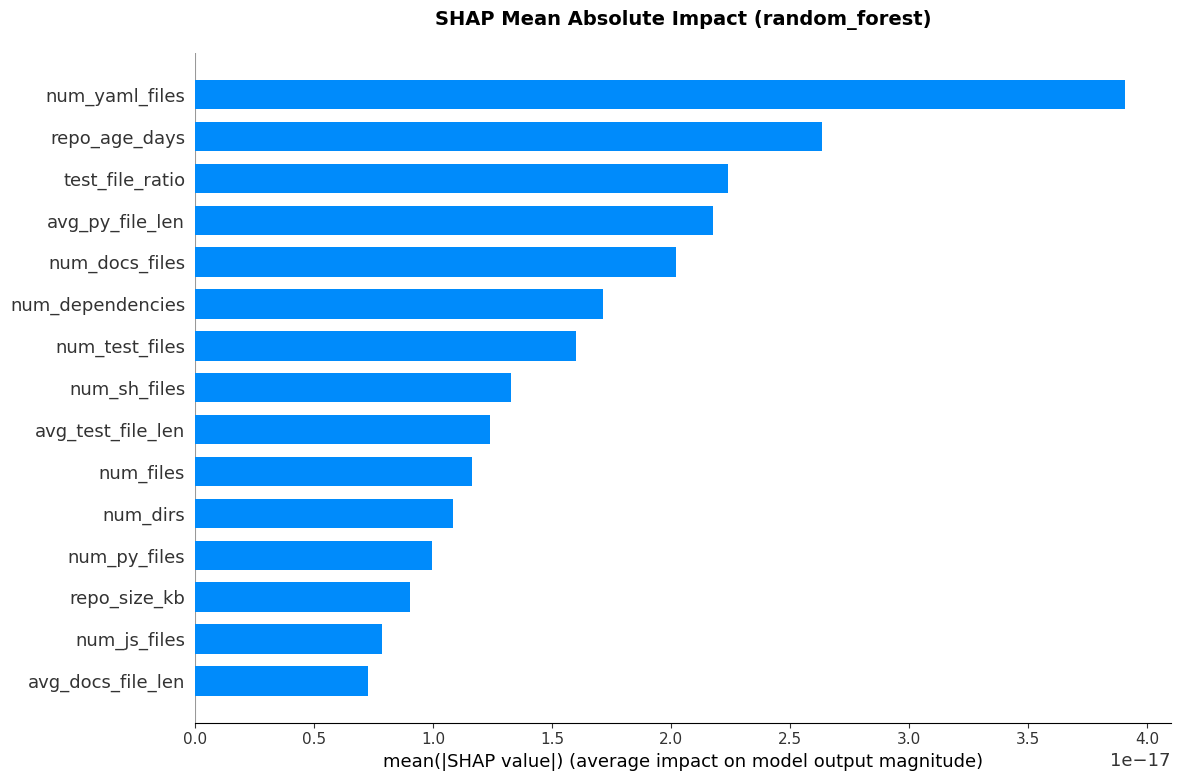

/tmp/ipykernel_1322/376128265.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


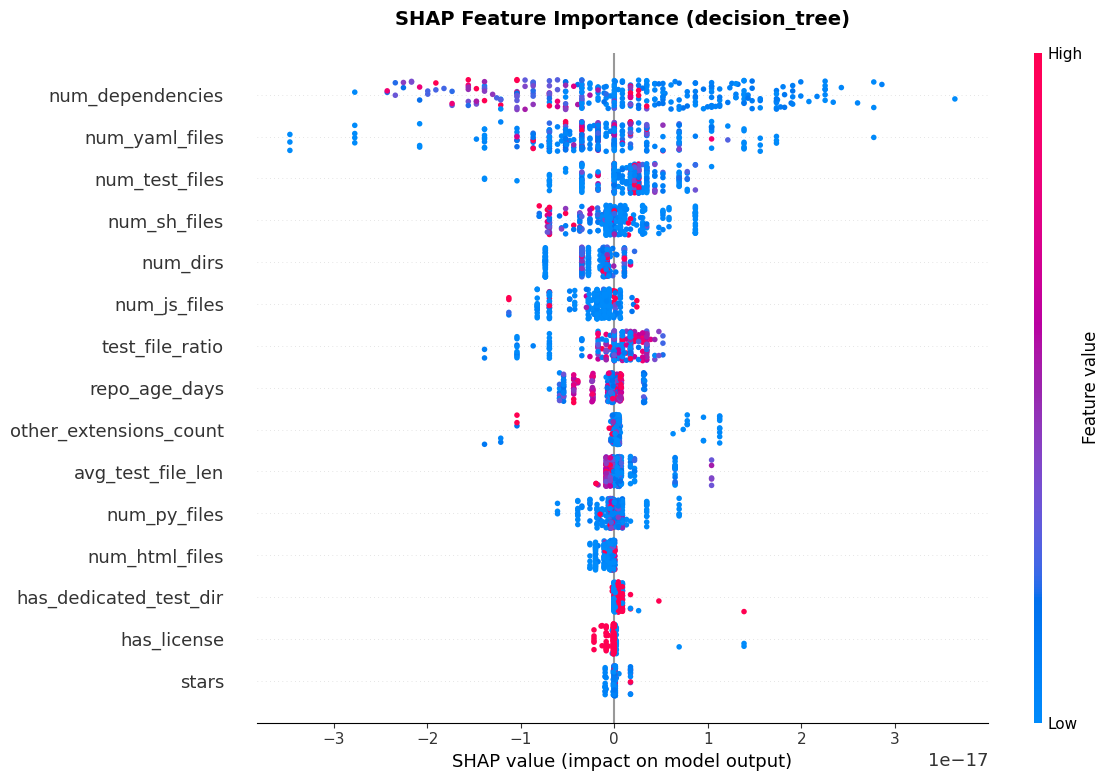

/tmp/ipykernel_1322/376128265.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


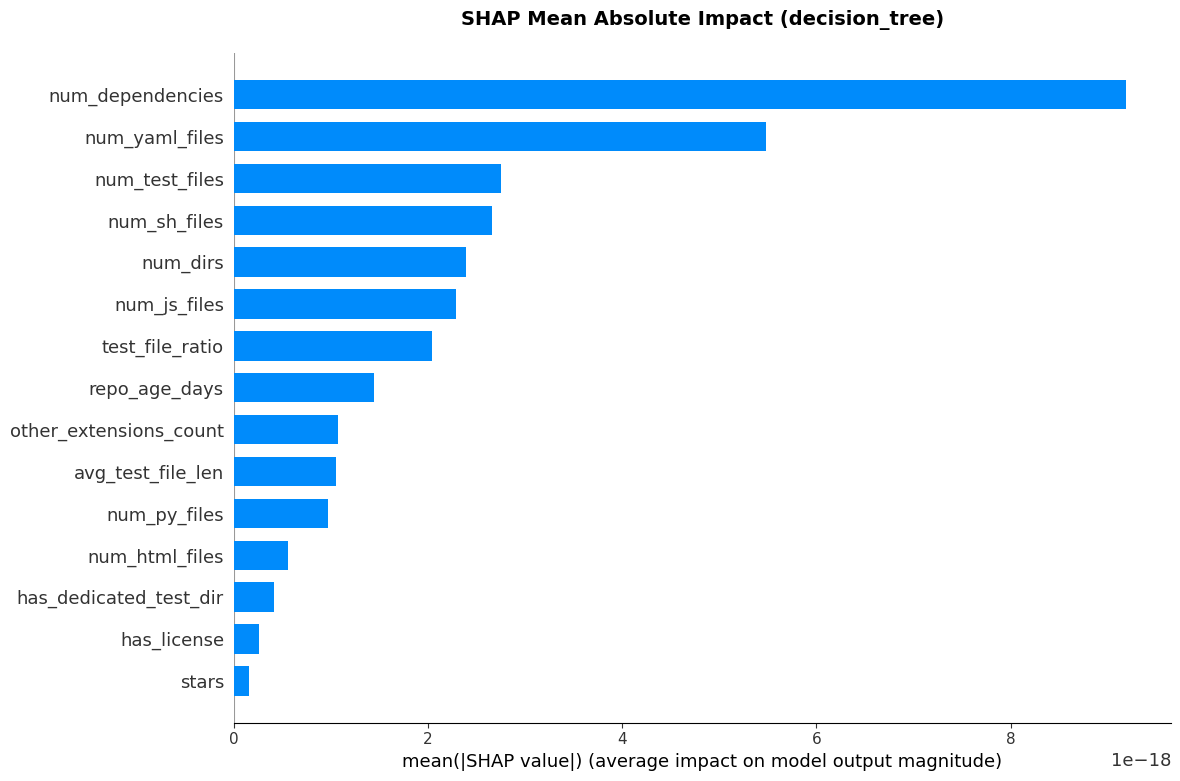

/tmp/ipykernel_1322/376128265.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


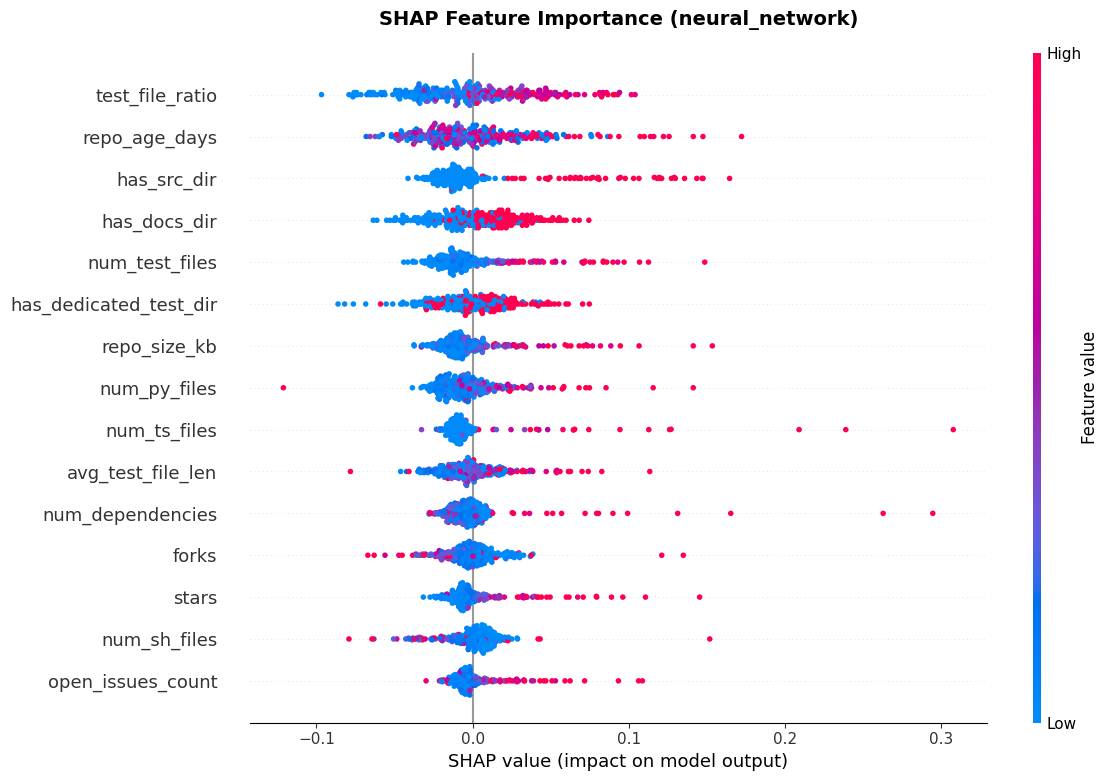

/tmp/ipykernel_1322/376128265.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


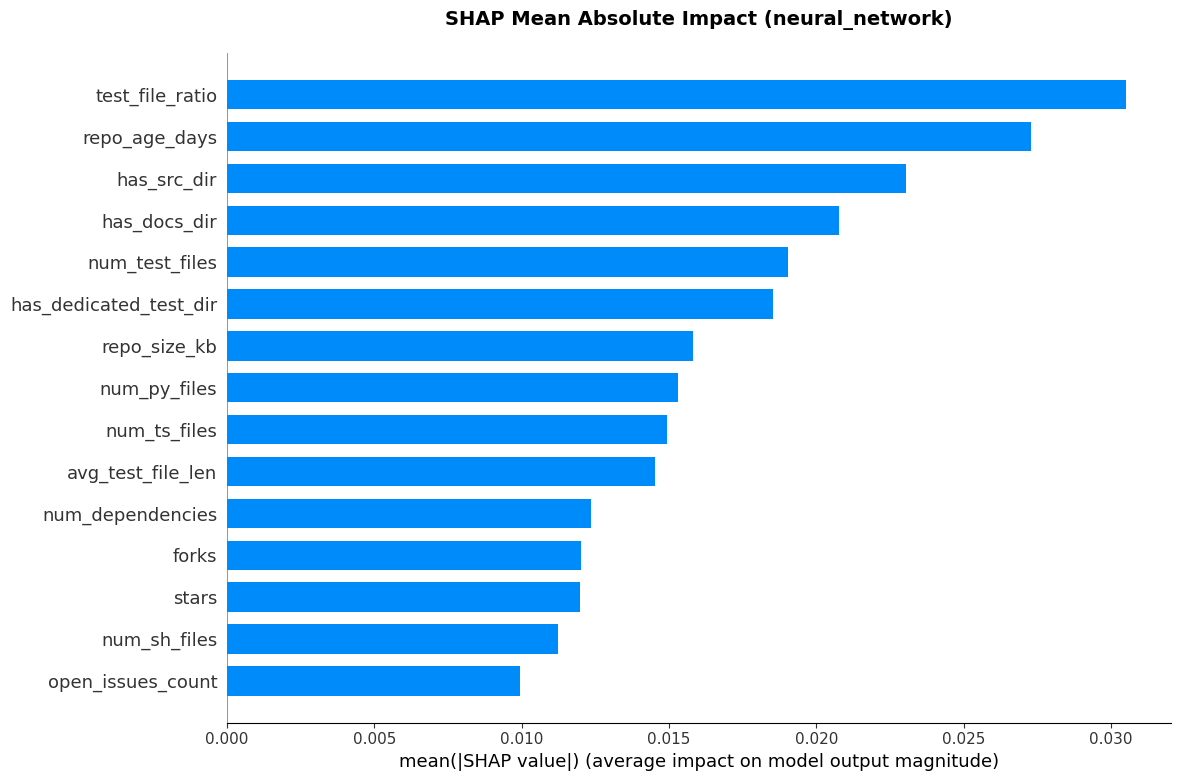

/tmp/ipykernel_1322/376128265.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


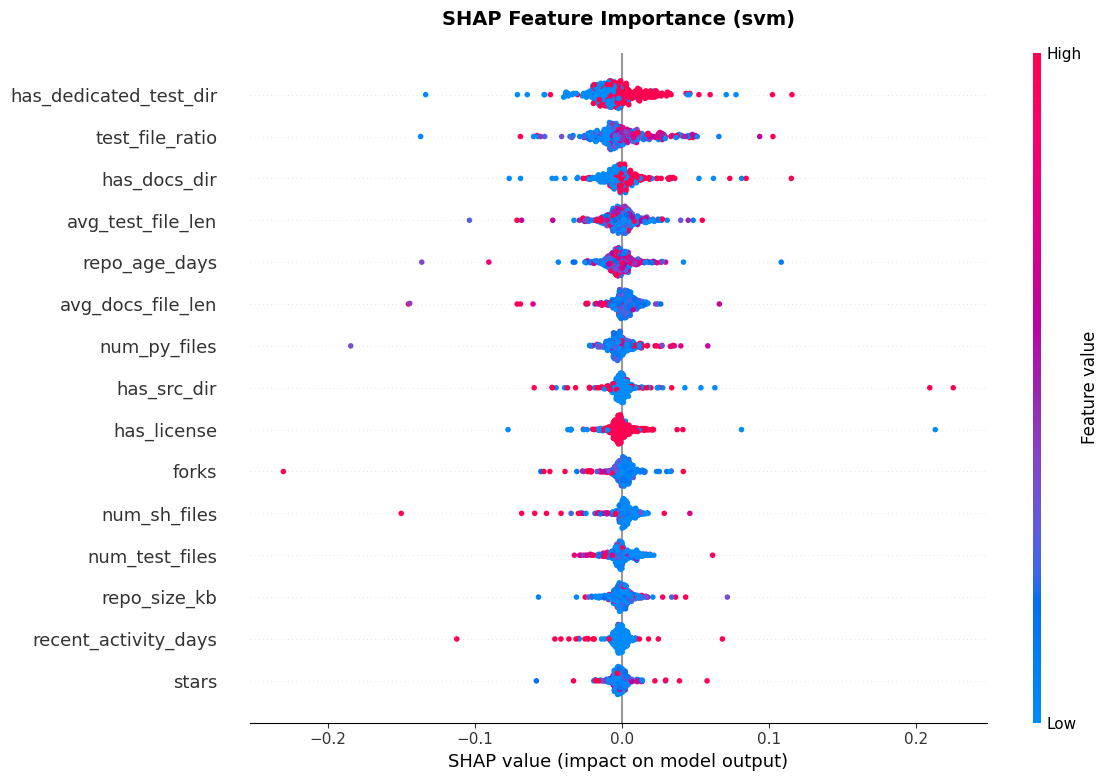

/tmp/ipykernel_1322/376128265.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


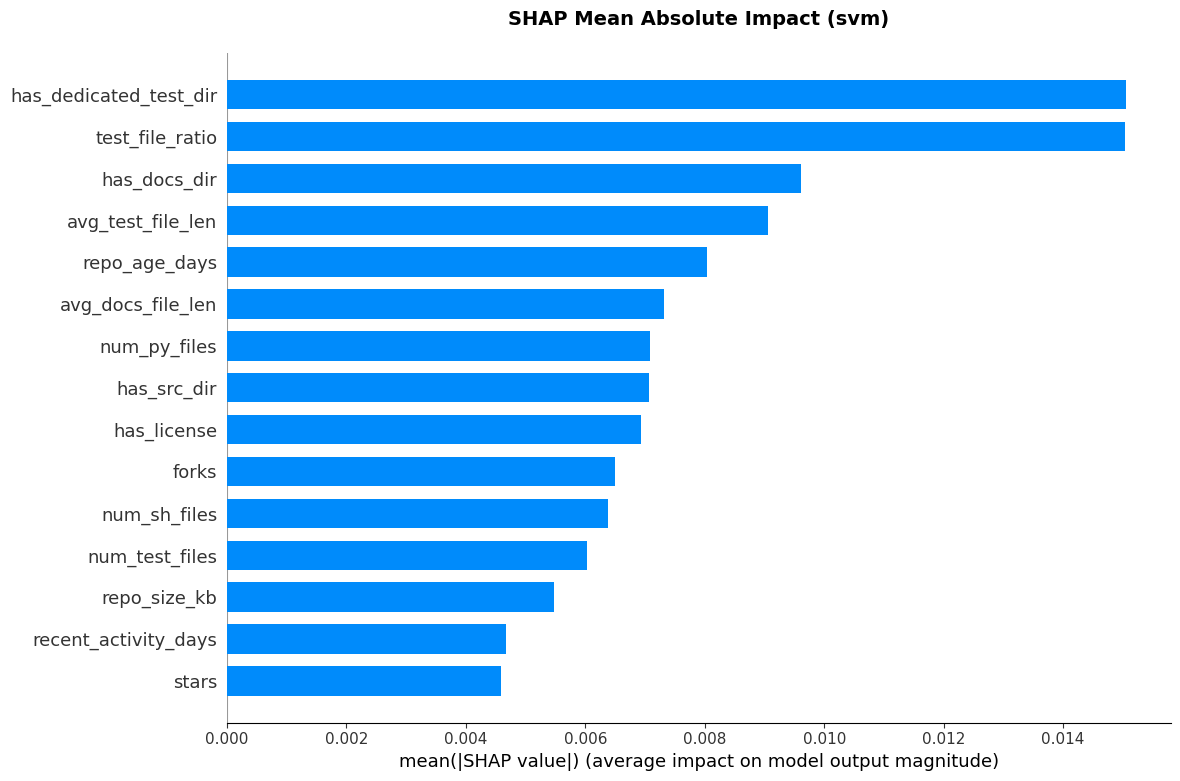

In [9]:
for family_key, shap_vals in shap_results.items():
    run_suffix = f"{artifact_version}_{selected_variant}_{family_key}"

    fig, _ = plt.subplots(figsize=(12, 10))
    shap.summary_plot(
        shap_vals, X_eval_df, max_display=15, show=False, plot_size=(12, 8)
    )
    plt.title(
        f"SHAP Feature Importance ({family_key})",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.tight_layout()
    plt.savefig(shap_dir / f"shap_summary_{run_suffix}.pdf")
    plt.show()

    fig, _ = plt.subplots(figsize=(12, 10))
    shap.summary_plot(
        shap_vals,
        X_eval_df,
        plot_type="bar",
        max_display=15,
        show=False,
        plot_size=(12, 8),
    )
    plt.title(
        f"SHAP Mean Absolute Impact ({family_key})",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.tight_layout()
    plt.savefig(shap_dir / f"shap_bar_{run_suffix}.pdf")
    plt.show()

## 6. Top SHAP Features (Class-Aggregate)


In [10]:
importance_frames: list[pd.DataFrame] = []

for family_key, shap_vals in shap_results.items():
    mean_abs_shap = np.abs(shap_vals.values).mean(axis=0)
    shap_importance = pd.DataFrame(
        {"feature": feature_cols, "mean_abs_shap": mean_abs_shap}
    ).sort_values("mean_abs_shap", ascending=False)
    shap_importance["variant"] = selected_variant
    shap_importance["model_family"] = family_key
    shap_importance["training_run_id"] = selected_run_dir.name
    shap_importance["artifact_version"] = artifact_version
    importance_frames.append(shap_importance)

    family_path = shap_dir / (
        f"shap_importance_{artifact_version}_{selected_variant}_{family_key}.csv"
    )
    shap_importance.to_csv(family_path, index=False)

combined_importance = pd.concat(importance_frames, ignore_index=True)
combined_path = (
    shap_dir / f"shap_importance_combined_{artifact_version}_{selected_variant}.csv"
)
combined_importance.to_csv(combined_path, index=False)

display(combined_importance.head(20))
print(f"Saved combined importance: {combined_path}")

,feature,mean_abs_shap,variant,model_family,training_run_id,artifact_version
0,num_yaml_files,0.058241,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
1,test_file_ratio,0.028759,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
2,num_dependencies,0.026933,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
3,avg_test_file_len,0.016941,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
4,num_sh_files,0.016006,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
5,repo_age_days,0.015196,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
6,num_test_files,0.014543,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
7,forks,0.012361,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
8,open_issues_count,0.012200,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1
9,stars,0.012137,original,gradient_boosting,20260413_155156,20260413_155156_v1.0.1


Saved combined importance: artifacts/shap/20260413_155156_v1.0.1/shap_importance_combined_20260413_155156_v1.0.1_original.csv


## 7. Feature Group Importance Summary

Grouped SHAP summary for the best model family, showing whether repository metadata, structural/content, or configuration-oriented characteristics contribute most to predictions.

In [11]:
def _classify_feature(feature: str) -> str:
    if feature in metadata_features:
        return "Repository metadata"
    if any(keyword in feature for keyword in config_keywords):
        return "Configuration-oriented"
    return "Structural/content"


best_family_key = best_model_family.value
best_family_importance = combined_importance[
    combined_importance["model_family"] == best_family_key
].copy()

if best_family_importance.empty:
    raise ValueError(
        f"No SHAP importance rows found for model family: {best_family_key}"
    )

metadata_features = {
    "stars",
    "forks",
    "repo_size_kb",
    "open_issues_count",
    "repo_age_days",
    "recent_activity_days",
}
config_keywords = (
    "yaml",
    "json",
    "dependencies",
    "scripts",
    "docker",
    "workflow",
    "precommit",
    "tox",
    "makefile",
    "sh_files",
)

best_family_importance["feature_group"] = best_family_importance["feature"].map(
    _classify_feature
)

total_importance = best_family_importance["mean_abs_shap"].sum()
group_summary = (
    best_family_importance.groupby("feature_group", as_index=False)["mean_abs_shap"]
    .sum()
    .rename(columns={"mean_abs_shap": "group_importance"})
)
group_summary["share_pct"] = 100 * group_summary["group_importance"] / total_importance

top_per_group = (
    best_family_importance.sort_values("mean_abs_shap", ascending=False)
    .groupby("feature_group", as_index=False)
    .head(3)
)
top_per_group["feature_rank"] = top_per_group.apply(
    lambda row: f"{row['feature']} ({row['mean_abs_shap']:.4f})", axis=1
)
top_features = (
    top_per_group.groupby("feature_group")["feature_rank"]
    .apply(lambda s: ", ".join(s))
    .reset_index(name="Top features")
)

group_table = (
    group_summary.merge(top_features, on="feature_group", how="left")
    .sort_values("share_pct", ascending=False)
    .reset_index(drop=True)
)
group_table = group_table.rename(
    columns={
        "feature_group": "Feature group",
        "share_pct": "Share of total importance (%)",
    }
)
group_table["Share of total importance (%)"] = group_table[
    "Share of total importance (%)"
].round(2)
group_table["Model family"] = best_family_key
group_table = group_table[
    [
        "Model family",
        "Feature group",
        "Share of total importance (%)",
        "Top features",
    ]
]

group_table_path = shap_dir / (
    f"shap_group_importance_{artifact_version}_{selected_variant}_{best_family_key}.csv"
)
group_table.to_csv(group_table_path, index=False)

display(group_table)
print(f"Saved grouped SHAP importance: {group_table_path}")

,Model family,Feature group,Share of total importance (%),Top features
0,gradient_boosting,Structural/content,50.94,"test_file_ratio (0.0288), avg_test_file_len (0..."
1,gradient_boosting,Configuration-oriented,31.12,"num_yaml_files (0.0582), num_dependencies (0.0..."
2,gradient_boosting,Repository metadata,17.94,"repo_age_days (0.0152), forks (0.0124), open_i..."


Saved grouped SHAP importance: artifacts/shap/20260413_155156_v1.0.1/shap_group_importance_20260413_155156_v1.0.1_original_gradient_boosting.csv
